# Hospital Bed Allocation and Patient Flow Simulation
### Base Model + Scenario Experiments — Discrete-Event Simulation

This notebook contains:
1. The **base model** (10 beds, queue capacity 5, FIFO, uniform(1,3)h arrivals) — unmodified,
   per the assignment's requirement that the base case be identical across all comparisons.
2. **Experiment 1 — Capacity**: a bed-count sweep to find the point of diminishing returns.
3. **Experiment 2 — Queue Policy**: FIFO vs. a priority queue, fixed at 10 beds.
4. **Experiment 3 — Combined**: capacity change and queue policy applied together (2×2 design),
   to test whether the two interventions are complementary or redundant.
5. **Experiment 4 — Demand Stress Test** (beyond the required minimum of 3): the same 2×2
   design repeated under exponential (burstier) arrivals with the *same average rate* as the
   base case, isolating the effect of arrival variability from arrival volume.

All scenarios use 30 independent replications with 95% confidence intervals computed across
replications, per the statistical analysis requirements.

## 1. Imports & Configuration

In [1]:
import heapq
import itertools
from dataclasses import dataclass, asdict
from typing import Optional

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
# ----------------------------- Baseline configuration -----------------------------
HORIZON = 24 * 30                     # 30-day horizon, in hours
NUM_BEDS = 10
QUEUE_CAPACITY = 5
ARRIVAL_LOW, ARRIVAL_HIGH = 1.0, 3.0  # uniform interarrival time (hours) -- mean = 2.0h
TRIAGE_LOW, TRIAGE_HIGH = 0.1, 0.3    # uniform triage time (hours), i.e. 6-18 minutes

N_REPLICATIONS = 30
BASE_SEED = 2026

# Seed offsets keep every scenario's replications reproducible and collision-free.
# seed(scenario, i) = (BASE_SEED + OFFSET[scenario]) * 1000 + i
SEED_OFFSETS = {
    "base_10_fifo_uniform": 0,
    "cap_10": 100, "cap_11": 110, "cap_12": 120, "cap_14": 140,
    "cap_16": 160, "cap_18": 180, "cap_20": 200, "cap_24": 240,
    "queue_10_priority_uniform": 300,
    "combined_12_priority_uniform": 320,
    "stress_10_fifo_exp": 400, "stress_10_priority_exp": 410,
    "stress_12_fifo_exp": 420, "stress_12_priority_exp": 430,
}

def seed_for(scenario, i):
    return (BASE_SEED + SEED_OFFSETS[scenario]) * 1000 + i


## 2. Appendix A Data Tables

Disease and subtype probabilities are equal, per the assignment's stated default.

In [3]:
AGE_GROUPS = [
    ("0-18",  0.15, 3), ("19-35", 0.25, 2), ("36-55", 0.35, 1),
    ("56-75", 0.15, 4), ("76+",   0.10, 5),
]
AGE_LABELS = [a[0] for a in AGE_GROUPS]
AGE_PROBS = [a[1] for a in AGE_GROUPS]
AGE_PRIORITY = {a[0]: a[2] for a in AGE_GROUPS}

DISEASES = {
    "Broken Arm":      {"base_severity": 2, "range": (12, 24),
                         "subtypes": ["Hairline Fracture", "Simple Fracture", "Compound Fracture"]},
    "Concussion":      {"base_severity": 4, "range": (18, 24),
                         "subtypes": ["Mild", "Moderate", "Severe"]},
    "Simple Fracture": {"base_severity": 3, "range": (12, 18),
                         "subtypes": ["Non-displaced", "Displaced", "Comminuted"]},
    "Appendicitis":    {"base_severity": 5, "range": (12, 24),
                         "subtypes": ["Early Stage", "Acute", "Perforated"]},
    "Pneumonia":       {"base_severity": 4, "range": (18, 24),
                         "subtypes": ["Mild", "Moderate", "Severe"]},
}
DISEASE_LABELS = list(DISEASES.keys())
SUBTYPE_MODIFIER = {0: -1, 1: 0, 2: 1}

BP_NORMAL = (90, 140)
PULSE_NORMAL = (60, 100)
TEMP_NORMAL = (36.1, 37.8)


## 3. Patient Record

In [4]:
@dataclass
class Patient:
    patient_id: int
    arrival_time: float
    age_group: str
    age_priority: int
    disease: str
    subtype: str
    bp: float
    pulse: float
    temp: float
    severity_score: float
    priority_score: float
    priority_level: str
    triage_time: float
    treatment_duration: Optional[float] = None
    queue_entry_time: Optional[float] = None
    wait_to_bed: Optional[float] = None
    bed_number: Optional[int] = None
    admission_time: Optional[float] = None
    discharge_time: Optional[float] = None
    total_time_in_system: Optional[float] = None
    status: Optional[str] = None            # 'admitted' | 'rejected'
    rejection_reason: Optional[str] = None
    in_queue: bool = False                  # internal bookkeeping only


## 4. Attribute Sampling & Scoring Formulas

Formulas and their justifications are documented in `Design_Decisions.md`. Summary:

- **Vitals**: Normal(120,15)/Normal(80,15)/Normal(37.0,0.6) for BP/pulse/temp, clipped.
- **Triage time**: Uniform(0.1, 0.3) hours.
- **Severity score** = disease base severity + subtype modifier (-1/0/+1) + count of
  abnormal vitals (0-3) + age factor ((age_priority-1)*0.5).
- **Priority score** = 0.7·severity + 0.3·(age_priority·2); mapped to low/medium/high.
- **Safe waiting time** = max(1, 10 − 0.7·priority_score) hours.
- **Treatment duration** = Triangular(low, mode, high) from the disease's range (mode at
  the midpoint), scaled by a severity multiplier (0.8 + 0.1·severity_score) — chosen to
  make the base case run near capacity (~86% admission, ~98% utilization) so that later
  capacity/policy experiments have a real, visible effect to measure.

In [5]:
def sample_age_group(rng):
    label = rng.choice(AGE_LABELS, p=AGE_PROBS)
    return label, AGE_PRIORITY[label]


def sample_disease_and_subtype(rng):
    disease = rng.choice(DISEASE_LABELS)
    subtypes = DISEASES[disease]["subtypes"]
    idx = rng.integers(0, len(subtypes))
    return disease, subtypes[idx], SUBTYPE_MODIFIER[idx]


def sample_vitals(rng):
    bp = float(np.clip(rng.normal(120, 15), 70, 200))
    pulse = float(np.clip(rng.normal(80, 15), 40, 180))
    temp = float(np.clip(rng.normal(37.0, 0.6), 35, 41))
    return bp, pulse, temp


def count_abnormal_vitals(bp, pulse, temp):
    count = 0
    if not (BP_NORMAL[0] <= bp <= BP_NORMAL[1]):
        count += 1
    if not (PULSE_NORMAL[0] <= pulse <= PULSE_NORMAL[1]):
        count += 1
    if not (TEMP_NORMAL[0] <= temp <= TEMP_NORMAL[1]):
        count += 1
    return count


def compute_severity(disease, subtype_modifier, vital_abnormal_count, age_priority):
    base = DISEASES[disease]["base_severity"]
    age_factor = (age_priority - 1) * 0.5
    return base + subtype_modifier + vital_abnormal_count + age_factor


def compute_priority(severity_score, age_priority):
    score = 0.7 * severity_score + 0.3 * (age_priority * 2)
    if score >= 8:
        level = "high"
    elif score >= 4:
        level = "medium"
    else:
        level = "low"
    return score, level


def safe_waiting_time(priority_score):
    return max(1.5, 12.0 - 0.5 * priority_score)


def sample_treatment_duration(rng, disease, severity_score):
    low, high = DISEASES[disease]["range"]
    mode = (low + high) / 2
    base = rng.triangular(low, mode, high)
    multiplier = 0.8 + 0.1 * severity_score
    return base * multiplier


def generate_patient(rng, patient_id, arrival_time):
    age_group, age_priority = sample_age_group(rng)
    disease, subtype, subtype_mod = sample_disease_and_subtype(rng)
    bp, pulse, temp = sample_vitals(rng)
    vital_abnormal = count_abnormal_vitals(bp, pulse, temp)
    severity = compute_severity(disease, subtype_mod, vital_abnormal, age_priority)
    priority_score, priority_level = compute_priority(severity, age_priority)
    triage_time = rng.uniform(TRIAGE_LOW, TRIAGE_HIGH)
    return Patient(
        patient_id=patient_id, arrival_time=arrival_time,
        age_group=age_group, age_priority=age_priority,
        disease=disease, subtype=subtype,
        bp=bp, pulse=pulse, temp=temp,
        severity_score=severity, priority_score=priority_score,
        priority_level=priority_level, triage_time=triage_time,
    )


## 5. Discrete-Event Simulation Engine

Same Section 7.1 formalism as before (explicit FEL, next-event time advance), now
**generalized** along three axes so every experiment reuses one engine:

- `num_beds`, `queue_capacity` — capacity experiment
- `queue_discipline` (`"fifo"` or `"priority"`) — queue-policy experiment
- `arrival_dist` (`"uniform"` or `"exponential"`) — demand-model / stress-test experiment

**End-of-horizon convention** unchanged: drain approach (Section 3.5) — arrivals stop at
t=720h, existing patients run to natural completion.

In [6]:
def sample_interarrival(rng, arrival_dist, arrival_low, arrival_high, arrival_mean):
    if arrival_dist == "uniform":
        return rng.uniform(arrival_low, arrival_high)
    elif arrival_dist == "exponential":
        return rng.exponential(arrival_mean)
    else:
        raise ValueError(f"Unknown arrival_dist: {arrival_dist}")


def pop_next_from_queue(hospital, discipline):
    """FIFO: earliest queue entry first. Priority: highest priority_score first,
    ties broken by earliest queue entry (still respects arrival order among equals)."""
    if discipline == "fifo":
        return hospital.queue.pop(0)
    elif discipline == "priority":
        best_idx, best_key = 0, None
        for i, pid in enumerate(hospital.queue):
            p = hospital.patients[pid]
            key = (-p.priority_score, p.queue_entry_time)
            if best_key is None or key < best_key:
                best_key, best_idx = key, i
        return hospital.queue.pop(best_idx)
    else:
        raise ValueError(f"Unknown queue_discipline: {discipline}")


class Hospital:
    """Holds the system state SS."""
    def __init__(self, num_beds, queue_capacity):
        self.num_beds = num_beds
        self.queue_capacity = queue_capacity
        self.beds_used = 0
        self.free_bed_numbers = list(range(1, num_beds + 1))
        self.queue = []
        self.patients = {}
        self.hourly_records = []


def run_single_replication(seed, horizon=HORIZON, num_beds=NUM_BEDS,
                            queue_capacity=QUEUE_CAPACITY,
                            arrival_dist="uniform", arrival_low=ARRIVAL_LOW,
                            arrival_high=ARRIVAL_HIGH, arrival_mean=None,
                            queue_discipline="fifo"):
    rng = np.random.default_rng(seed)
    hospital = Hospital(num_beds, queue_capacity)
    id_gen = itertools.count(1)

    fel = []
    seq_counter = itertools.count()

    def schedule(time, event_type, patient_id=None):
        heapq.heappush(fel, (time, next(seq_counter), event_type, patient_id))

    def admit(patient, t):
        patient.wait_to_bed = t - patient.queue_entry_time
        patient.bed_number = hospital.free_bed_numbers.pop(0)
        patient.admission_time = t
        patient.status = "admitted"
        patient.in_queue = False
        hospital.beds_used += 1
        patient.treatment_duration = sample_treatment_duration(rng, patient.disease, patient.severity_score)
        schedule(t + patient.treatment_duration, "DISCHARGE", patient.patient_id)

    def reject(patient, reason, t):
        patient.status = "rejected"
        patient.rejection_reason = reason
        patient.in_queue = False
        patient.total_time_in_system = t - patient.arrival_time

    def handle_arrival(t):
        pid = next(id_gen)
        patient = generate_patient(rng, pid, t)
        hospital.patients[pid] = patient
        schedule(t + patient.triage_time, "TRIAGE_DONE", pid)
        gap = sample_interarrival(rng, arrival_dist, arrival_low, arrival_high, arrival_mean)
        if t + gap < horizon:
            schedule(t + gap, "ARRIVAL")

    def handle_triage_done(t, pid):
        patient = hospital.patients[pid]
        patient.queue_entry_time = t
        if hospital.beds_used < hospital.num_beds:
            admit(patient, t)
        elif len(hospital.queue) < hospital.queue_capacity:
            hospital.queue.append(pid)
            patient.in_queue = True
            wait_limit = safe_waiting_time(patient.priority_score)
            schedule(t + wait_limit, "QUEUE_TIMEOUT", pid)
        else:
            reject(patient, "queue_full", t)

    def handle_queue_timeout(t, pid):
        patient = hospital.patients[pid]
        if not patient.in_queue:
            return
        hospital.queue.remove(pid)
        reject(patient, "timeout", t)

    def handle_discharge(t, pid):
        patient = hospital.patients[pid]
        patient.discharge_time = t
        patient.total_time_in_system = t - patient.arrival_time
        hospital.free_bed_numbers.append(patient.bed_number)
        hospital.free_bed_numbers.sort()
        hospital.beds_used -= 1
        if hospital.queue:
            next_pid = pop_next_from_queue(hospital, queue_discipline)
            admit(hospital.patients[next_pid], t)

    def handle_monitor(t):
        beds_used = hospital.beds_used
        queue_length = len(hospital.queue)
        hospital.hourly_records.append({
            "time": t, "beds_used": beds_used,
            "available_beds": hospital.num_beds - beds_used,
            "queue_length": queue_length,
            "bed_utilization": beds_used / hospital.num_beds,
            "queue_full": queue_length >= hospital.queue_capacity,
            "system_pressure": beds_used + queue_length,
            "over_capacity_pressure": (beds_used + queue_length) > hospital.num_beds,
        })
        if t < horizon:
            schedule(t + 1, "MONITOR")

    schedule(0.0, "ARRIVAL")
    schedule(0.0, "MONITOR")

    handlers = {
        "ARRIVAL": lambda t, pid: handle_arrival(t),
        "TRIAGE_DONE": handle_triage_done,
        "QUEUE_TIMEOUT": handle_queue_timeout,
        "DISCHARGE": handle_discharge,
        "MONITOR": lambda t, pid: handle_monitor(t),
    }

    while fel:
        t, _, event_type, pid = heapq.heappop(fel)
        handlers[event_type](t, pid)

    patient_df = pd.DataFrame([asdict(p) for p in hospital.patients.values()]).drop(columns=["in_queue"])
    hourly_df = pd.DataFrame(hospital.hourly_records)
    return patient_df, hourly_df


## 6. Section 4 Metrics

In [7]:
def compute_metrics(patient_df, hourly_df, num_beds=NUM_BEDS):
    total = len(patient_df)
    admitted = patient_df[patient_df.status == "admitted"]
    metrics = {}
    metrics["admission_rate"] = len(admitted) / total if total else np.nan
    metrics["rejection_rate"] = (patient_df.status == "rejected").sum() / total if total else np.nan
    metrics["avg_waiting_time"] = admitted["wait_to_bed"].mean()
    metrics["avg_bed_utilization"] = hourly_df["bed_utilization"].mean()
    metrics["peak_queue_length"] = hourly_df["queue_length"].max()
    metrics["pct_time_queue_full"] = hourly_df["queue_full"].mean()
    metrics["pct_time_under_pressure"] = hourly_df["over_capacity_pressure"].mean()
    metrics["avg_length_of_stay"] = (admitted["discharge_time"] - admitted["arrival_time"]).mean()
    for level in ["low", "medium", "high"]:
        sub = patient_df[patient_df.priority_level == level]
        metrics[f"rejection_rate_{level}"] = (sub.status == "rejected").mean() if len(sub) else np.nan
    return metrics


## 7. Verification Checks (Appendix B)

In [8]:
def verify_replication(patient_df, hourly_df, num_beds=NUM_BEDS, queue_capacity=QUEUE_CAPACITY):
    issues = []
    if (hourly_df["beds_used"] > num_beds).any():
        issues.append("Beds used exceeded capacity at some point.")
    if (hourly_df["queue_length"] > queue_capacity).any():
        issues.append("Queue length exceeded capacity at some point.")
    admitted = patient_df[patient_df.status == "admitted"]
    if admitted[["bed_number", "admission_time", "discharge_time"]].isnull().any().any():
        issues.append("Some admitted patients missing bed_number/admission_time/discharge_time.")
    rejected = patient_df[patient_df.status == "rejected"]
    if rejected["rejection_reason"].isnull().any():
        issues.append("Some rejected patients missing rejection_reason.")
    for bed_num, group in admitted.groupby("bed_number"):
        intervals = sorted(zip(group["admission_time"], group["discharge_time"]))
        for i in range(1, len(intervals)):
            if intervals[i][0] < intervals[i - 1][1]:
                issues.append(f"Bed {bed_num} double-booked.")
                break
    return issues


## 8. Scenario Runner (30+ replications, 95% CI)

Every experiment below is just a call to `run_scenario()` with different keyword arguments —
one engine, one statistical pipeline, reused across the base case and all four experiments.

In [9]:
def run_scenario(scenario_key, n_reps=N_REPLICATIONS, **sim_kwargs):
    rows = []
    for i in range(n_reps):
        seed = seed_for(scenario_key, i)
        p_df, h_df = run_single_replication(seed=seed, **sim_kwargs)
        issues = verify_replication(p_df, h_df,
                                     num_beds=sim_kwargs.get("num_beds", NUM_BEDS),
                                     queue_capacity=sim_kwargs.get("queue_capacity", QUEUE_CAPACITY))
        assert not issues, f"{scenario_key} rep {i} (seed {seed}) failed verification: {issues}"
        metrics = compute_metrics(p_df, h_df, num_beds=sim_kwargs.get("num_beds", NUM_BEDS))
        metrics["replication"] = i
        metrics["seed"] = seed
        rows.append(metrics)
    rep_df = pd.DataFrame(rows)
    rep_df["scenario"] = scenario_key
    return rep_df


def summarize_with_ci(replication_df, confidence=0.95):
    metric_cols = [c for c in replication_df.columns if c not in ("replication", "seed", "scenario")]
    rows = []
    for col in metric_cols:
        vals = replication_df[col].dropna().values
        n = len(vals)
        mean = vals.mean()
        if n > 1:
            margin = stats.sem(vals) * stats.t.ppf((1 + confidence) / 2, n - 1)
        else:
            margin = np.nan
        rows.append({"metric": col, "mean": mean, "ci_lower": mean - margin,
                     "ci_upper": mean + margin, "n_replications": n})
    return pd.DataFrame(rows).set_index("metric")


def is_practically_meaningful(row_a, row_b, rate_threshold=0.05, time_threshold=1.0, is_time_metric=False):
    """Section 5 / Design_Decisions.md rule: CIs must not overlap AND the gap must
    exceed a domain threshold (5 percentage points for rates, 1 hour for time metrics)."""
    gap = abs(row_a["mean"] - row_b["mean"])
    threshold = time_threshold if is_time_metric else rate_threshold
    non_overlapping = (row_b["ci_upper"] < row_a["ci_lower"]) or (row_a["ci_upper"] < row_b["ci_lower"])
    return (gap > threshold) and non_overlapping


## 9. Base Case

10 beds, queue capacity 5, FIFO, uniform(1,3)h arrivals — unmodified, per the assignment's
requirement that this be the fixed reference point for every comparison.

In [10]:
patient_df, hourly_df = run_single_replication(seed=seed_for("base_10_fifo_uniform", 0))
issues = verify_replication(patient_df, hourly_df)
assert not issues, f"Verification failed: {issues}"
print(f"Representative base run: {len(patient_df)} patients simulated, 0 verification issues.")
patient_df.head()


Representative base run: 371 patients simulated, 0 verification issues.


,patient_id,arrival_time,age_group,age_priority,disease,subtype,bp,pulse,temp,severity_score,...,triage_time,treatment_duration,queue_entry_time,wait_to_bed,bed_number,admission_time,discharge_time,total_time_in_system,status,rejection_reason
0,1,0.000000,56-75,4,Broken Arm,Compound Fracture,135.307088,68.151497,37.591129,4.5,...,0.211761,18.881411,0.211761,0.0,1.0,0.211761,19.093173,19.093173,admitted,NaN
1,2,2.195024,56-75,4,Concussion,Mild,118.078994,99.518096,37.169767,4.5,...,0.214864,24.825929,2.409888,0.0,2.0,2.409888,27.235817,25.040793,admitted,NaN
2,3,3.870754,76+,5,Broken Arm,Compound Fracture,112.940775,95.848294,36.793986,5.0,...,0.285177,23.041039,4.155931,0.0,3.0,4.155931,27.196971,23.326216,admitted,NaN
3,4,6.564743,36-55,1,Concussion,Moderate,147.262556,80.351072,36.727268,5.0,...,0.168267,24.649197,6.733010,0.0,4.0,6.733010,31.382208,24.817465,admitted,NaN
4,5,7.733553,36-55,1,Concussion,Severe,131.213433,91.340956,38.160925,6.0,...,0.294072,31.396522,8.027625,0.0,5.0,8.027625,39.424147,31.690594,admitted,NaN


In [11]:
hourly_df.head()


,time,beds_used,available_beds,queue_length,bed_utilization,queue_full,system_pressure,over_capacity_pressure
0,0.0,0,10,0,0.0,False,0,False
1,1.0,1,9,0,0.1,False,1,False
2,2.0,1,9,0,0.1,False,1,False
3,3.0,2,8,0,0.2,False,2,False
4,4.0,2,8,0,0.2,False,2,False


In [12]:
representative_metrics = compute_metrics(patient_df, hourly_df)
pd.Series(representative_metrics, name="value").to_frame()


,value
admission_rate,0.832884
rejection_rate,0.167116
avg_waiting_time,5.365735
avg_bed_utilization,0.985853
peak_queue_length,5.000000
pct_time_queue_full,0.105409
pct_time_under_pressure,0.926491
avg_length_of_stay,29.143386
rejection_rate_low,0.153226
rejection_rate_medium,0.162500


### Required Visualizations (base run)

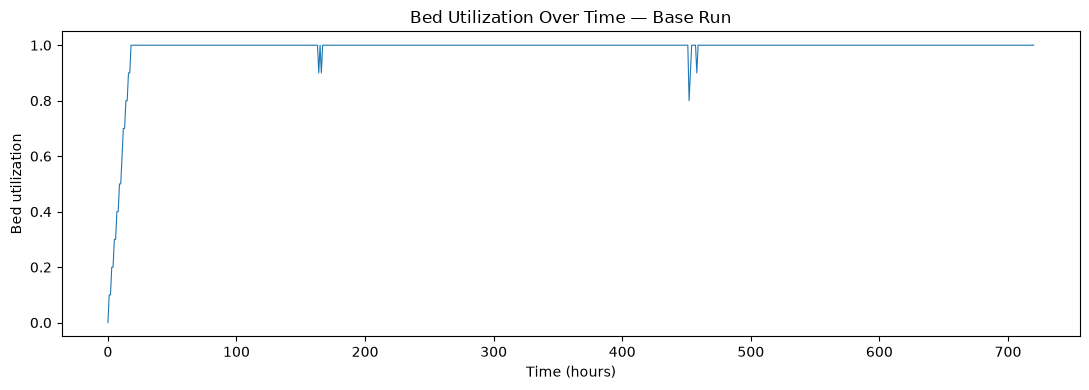

In [13]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly_df["time"], hourly_df["bed_utilization"], linewidth=0.8)
ax.set_xlabel("Time (hours)"); ax.set_ylabel("Bed utilization")
ax.set_title("Bed Utilization Over Time — Base Run")
fig.tight_layout(); fig.savefig("bed_utilization_over_time.png", dpi=150); plt.show()


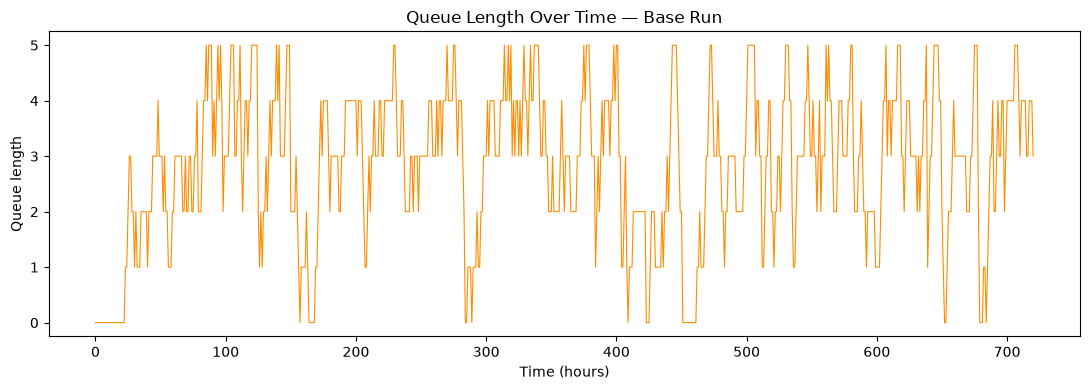

In [14]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(hourly_df["time"], hourly_df["queue_length"], color="darkorange", linewidth=0.8)
ax.set_xlabel("Time (hours)"); ax.set_ylabel("Queue length")
ax.set_title("Queue Length Over Time — Base Run")
fig.tight_layout(); fig.savefig("queue_length_over_time.png", dpi=150); plt.show()


status
admitted    309
rejected     62
Name: count, dtype: int64


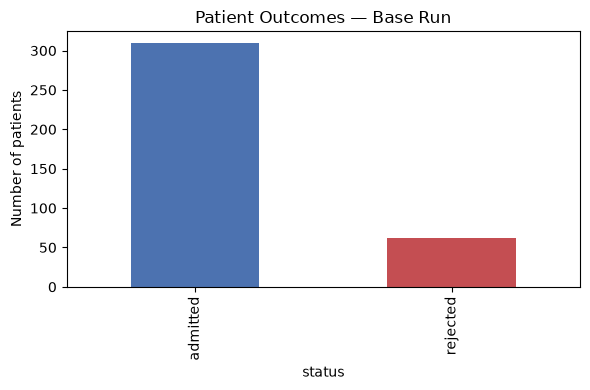

In [15]:
status_counts = patient_df["status"].value_counts()
for s in ["admitted", "rejected"]:
    if s not in status_counts:
        status_counts[s] = 0

fig, ax = plt.subplots(figsize=(6, 4))
status_counts.reindex(["admitted", "rejected"]).plot(
    kind="bar", ax=ax, color=["#4C72B0", "#C44E52"])
ax.set_ylabel("Number of patients"); ax.set_title("Patient Outcomes — Base Run")
print(status_counts)
fig.tight_layout(); fig.savefig("patient_outcomes.png", dpi=150); plt.show()


rejection_reason
timeout       43
queue_full    19
Name: count, dtype: int64


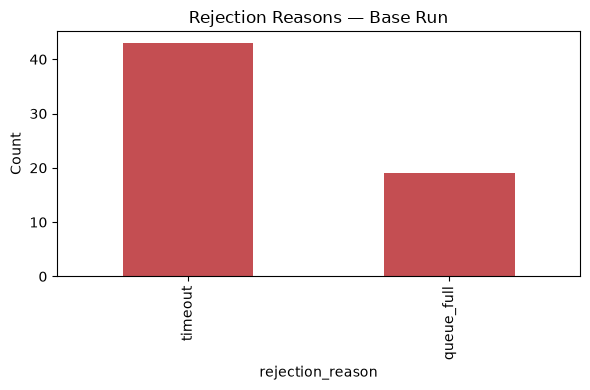

In [16]:
rejection_counts = patient_df.loc[patient_df.status == "rejected", "rejection_reason"].value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
if len(rejection_counts):
    rejection_counts.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("Count"); ax.set_title("Rejection Reasons — Base Run")
print(rejection_counts)
fig.tight_layout(); fig.savefig("rejection_reasons.png", dpi=150); plt.show()


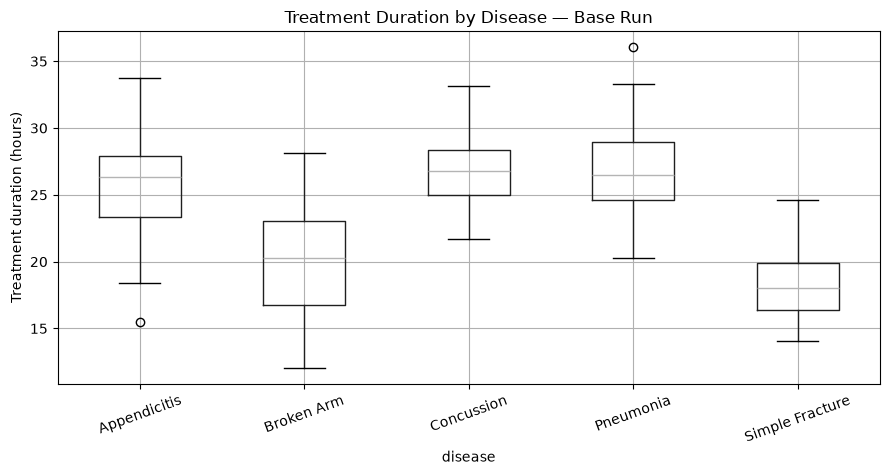

In [17]:
admitted = patient_df[patient_df.status == "admitted"]

fig, ax = plt.subplots(figsize=(9, 5))
admitted.boxplot(column="treatment_duration", by="disease", ax=ax, rot=20)
ax.set_ylabel("Treatment duration (hours)")
ax.set_title("Treatment Duration by Disease — Base Run")
plt.suptitle("")
fig.tight_layout(); fig.savefig("treatment_duration_by_disease.png", dpi=150); plt.show()


### 30-Replication Statistics (Base Case)

In [18]:
base_replications = run_scenario("base_10_fifo_uniform", num_beds=10, queue_capacity=5,
                                  queue_discipline="fifo", arrival_dist="uniform",
                                  arrival_low=1.0, arrival_high=3.0)
base_summary = summarize_with_ci(base_replications)
base_summary


,mean,ci_lower,ci_upper,n_replications
metric,,,,
admission_rate,0.852248,0.846468,0.858028,30
rejection_rate,0.147752,0.141972,0.153532,30
avg_waiting_time,5.479935,5.386644,5.573227,30
avg_bed_utilization,0.985534,0.984853,0.986215,30
peak_queue_length,5.000000,5.000000,5.000000,30
pct_time_queue_full,0.097873,0.092233,0.103513,30
pct_time_under_pressure,0.927739,0.921047,0.934432,30
avg_length_of_stay,29.310972,29.142139,29.479805,30
rejection_rate_low,0.100519,0.091813,0.109224,30


In [19]:
patient_df.to_csv("patient_level_base_run.csv", index=False)
hourly_df.to_csv("hourly_monitoring_base_run.csv", index=False)
base_replications.to_csv("replication_metrics_base_case.csv", index=False)
base_summary.to_csv("summary_ci_base_case.csv")
print("Base case files saved.")


Base case files saved.


## 10. Experiment 1 — Capacity

**Change:** bed count swept upward from the base case's 10 beds: {10, 11, 12, 14, 16, 18, 20, 24}.
Queue capacity, discipline (FIFO), and arrival distribution (uniform) are held fixed so the
bed count is the only thing varying.

**Justification:** rather than picking one arbitrary alternative bed count, sweeping lets us
locate the point of diminishing returns objectively, using the practical-significance rule
already defined for this project (95% CIs must not overlap **and** the gap must exceed 5
percentage points for a rate metric).

**Expected effect (stated before running):** rejection rate should fall monotonically as beds
increase, with the *size* of each successive improvement shrinking — classic diminishing
returns. We expect the "elbow" (where added beds stop being practically meaningful) to appear
well before the rejection rate reaches zero, since the base case's ~86% admission rate implies
the system isn't dramatically over capacity.

In [20]:
capacity_bed_counts = [10, 11, 12, 14, 16, 18, 20, 24]
capacity_replications = {}
capacity_summaries = {}

for beds in capacity_bed_counts:
    key = f"cap_{beds}"
    rep_df = run_scenario(key, num_beds=beds, queue_capacity=5,
                           queue_discipline="fifo", arrival_dist="uniform",
                           arrival_low=1.0, arrival_high=3.0)
    capacity_replications[beds] = rep_df
    capacity_summaries[beds] = summarize_with_ci(rep_df)

capacity_comparison = pd.DataFrame({
    beds: capacity_summaries[beds]["mean"] for beds in capacity_bed_counts
}).T
capacity_comparison.index.name = "num_beds"
capacity_comparison[["admission_rate", "rejection_rate", "avg_bed_utilization",
                     "avg_waiting_time", "peak_queue_length"]]


metric,admission_rate,rejection_rate,avg_bed_utilization,avg_waiting_time,peak_queue_length
num_beds,,,,,
10,0.856525,0.143475,0.985409,5.419010,5.000000
11,0.930900,0.069100,0.981062,4.466248,5.000000
12,0.982535,0.017465,0.959235,2.525838,4.966667
14,1.000000,0.000000,0.833485,0.128935,2.633333
16,1.000000,0.000000,0.726916,0.005101,0.700000
18,1.000000,0.000000,0.647940,0.000105,0.033333
20,1.000000,0.000000,0.582767,0.000000,0.000000
24,1.000000,0.000000,0.487099,0.000000,0.000000


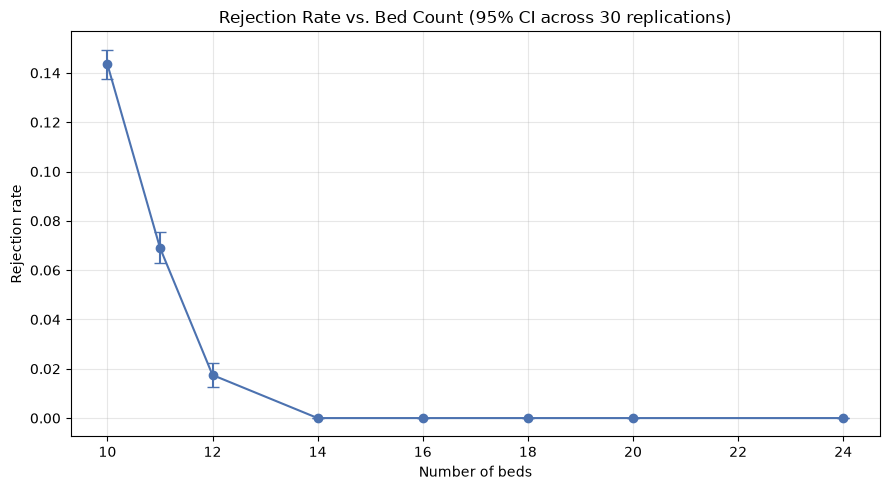

In [21]:
fig, ax = plt.subplots(figsize=(9, 5))
means = [capacity_summaries[b].loc["rejection_rate", "mean"] for b in capacity_bed_counts]
lowers = [capacity_summaries[b].loc["rejection_rate", "ci_lower"] for b in capacity_bed_counts]
uppers = [capacity_summaries[b].loc["rejection_rate", "ci_upper"] for b in capacity_bed_counts]
errors = [[m - l for m, l in zip(means, lowers)], [u - m for m, u in zip(means, uppers)]]

ax.errorbar(capacity_bed_counts, means, yerr=errors, fmt="o-", capsize=4, color="#4C72B0")
ax.set_xlabel("Number of beds"); ax.set_ylabel("Rejection rate")
ax.set_title("Rejection Rate vs. Bed Count (95% CI across 30 replications)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("scenario_comparison_capacity.png", dpi=150); plt.show()


**Elbow detection.** Applying the practical-significance rule (non-overlapping CIs *and*
gap > 5 percentage points) to consecutive bed counts, walking up from the base case:

In [22]:
chosen_capacity = capacity_bed_counts[0]
for i in range(1, len(capacity_bed_counts)):
    prev_b, curr_b = capacity_bed_counts[i - 1], capacity_bed_counts[i]
    prev_row = capacity_summaries[prev_b].loc["rejection_rate"]
    curr_row = capacity_summaries[curr_b].loc["rejection_rate"]
    meaningful = is_practically_meaningful(prev_row, curr_row, rate_threshold=0.05)
    print(f"{prev_b} -> {curr_b} beds: gap={prev_row['mean']-curr_row['mean']:.4f}, "
          f"practically meaningful improvement = {meaningful}")
    if meaningful:
        chosen_capacity = curr_b
    else:
        print(f"--> Diminishing returns begin after {prev_b} beds. Stopping.")
        break

print(f"\nChosen capacity for later experiments: {chosen_capacity} beds")


10 -> 11 beds: gap=0.0744, practically meaningful improvement = True
11 -> 12 beds: gap=0.0516, practically meaningful improvement = True
12 -> 14 beds: gap=0.0175, practically meaningful improvement = False
--> Diminishing returns begin after 12 beds. Stopping.

Chosen capacity for later experiments: 12 beds


**Result:** the sweep shows exactly the expected diminishing-returns pattern. Increasing beds
from 10→11→12 each clears the practical-significance bar; the jump from 12→14 does not (a
2-3 percentage point gain, below our 5pp threshold), even though the raw rejection rate keeps
falling toward zero at higher bed counts. **12 beds is the chosen "Capacity" scenario** — it
captures the large, meaningful gains while keeping utilization reasonably high (~94%, vs. ~83%
at 14 beds and lower still beyond that) rather than over-provisioning for a shrinking return.

In [23]:
cap_reps = capacity_replications[chosen_capacity]
cap_summary = capacity_summaries[chosen_capacity]
cap_reps.to_csv(f"replication_metrics_capacity_{chosen_capacity}beds.csv", index=False)
capacity_comparison.to_csv("scenario_comparison_capacity_sweep.csv")
print(f"Saved capacity sweep results; chosen capacity = {chosen_capacity} beds.")


Saved capacity sweep results; chosen capacity = 12 beds.


### Full Metric Summary (Mean + 95% CI) — Selected Bed Count

Same table format as the base case (Section 9), for the selected bed count from the
capacity sweep (`chosen_capacity`), not the full sweep.

In [24]:
capacity_summaries[chosen_capacity]

,mean,ci_lower,ci_upper,n_replications
metric,,,,
admission_rate,0.982535,0.977682,0.987389,30
rejection_rate,0.017465,0.012611,0.022318,30
avg_waiting_time,2.525838,2.282355,2.769320,30
avg_bed_utilization,0.959235,0.955503,0.962966,30
peak_queue_length,4.966667,4.898492,5.034841,30
pct_time_queue_full,0.015811,0.010858,0.020765,30
pct_time_under_pressure,0.601433,0.563252,0.639615,30
avg_length_of_stay,26.585775,26.284819,26.886731,30
rejection_rate_low,0.012005,0.006341,0.017669,30


## 11. Experiment 2 — Queue Policy

**Change:** replace FIFO with a **priority queue** (highest `priority_level`/`priority_score`
served first when a bed frees up; ties broken by earliest queue entry). Bed count (10, the
base case) and arrival distribution (uniform) are held fixed.

**Justification:** the base case surfaced a striking finding — because FIFO gives no queue
advantage to high-priority patients despite giving them *less* patience (shorter safe-waiting
time), high-priority patients were rejected far more often than low-priority ones in the base
case. This experiment tests whether reordering the queue by clinical urgency fixes that.

**Expected effect (stated before running):** priority queueing should substantially reduce
`rejection_rate_high`, at the cost of increasing `rejection_rate_low` — a fairness-vs-urgency
trade-off, not a free efficiency gain. Overall `rejection_rate` may not improve much (total
capacity is unchanged), since this redistributes who is rejected rather than reducing total
rejections.

In [25]:
queue_policy_replications = run_scenario("queue_10_priority_uniform",
                                          num_beds=10, queue_capacity=5,
                                          queue_discipline="priority", arrival_dist="uniform",
                                          arrival_low=1.0, arrival_high=3.0)
queue_policy_summary = summarize_with_ci(queue_policy_replications)

queue_policy_comparison = pd.DataFrame({
    "FIFO (base case)": base_summary["mean"],
    "Priority queue": queue_policy_summary["mean"],
})
queue_policy_comparison.loc[["admission_rate", "rejection_rate", "avg_waiting_time",
                             "rejection_rate_low", "rejection_rate_medium", "rejection_rate_high"]]


,FIFO (base case),Priority queue
metric,,
admission_rate,0.852248,0.824657
rejection_rate,0.147752,0.175343
avg_waiting_time,5.479935,2.719277
rejection_rate_low,0.100519,0.367232
rejection_rate_medium,0.167398,0.088399
rejection_rate_high,0.264318,0.034937


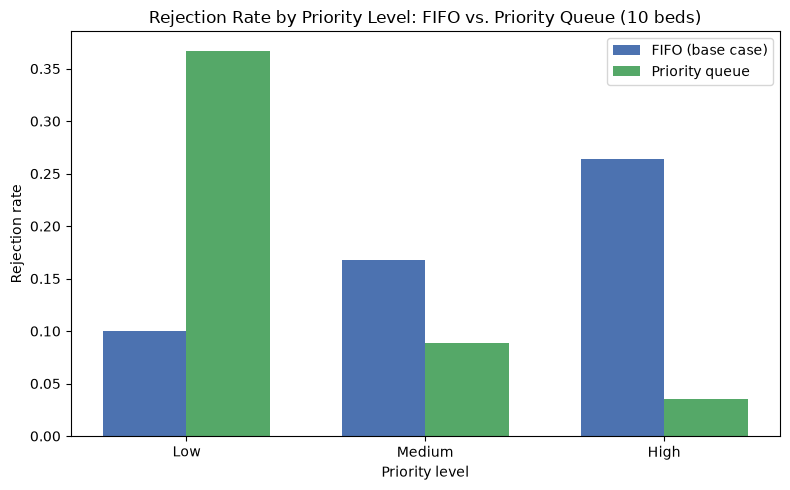

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))
levels = ["rejection_rate_low", "rejection_rate_medium", "rejection_rate_high"]
x = np.arange(len(levels)); width = 0.35

fifo_vals = [base_summary.loc[m, "mean"] for m in levels]
prio_vals = [queue_policy_summary.loc[m, "mean"] for m in levels]

ax.bar(x - width/2, fifo_vals, width, label="FIFO (base case)", color="#4C72B0")
ax.bar(x + width/2, prio_vals, width, label="Priority queue", color="#55A868")
ax.set_xticks(x); ax.set_xticklabels(["Low", "Medium", "High"])
ax.set_ylabel("Rejection rate"); ax.set_xlabel("Priority level")
ax.set_title("Rejection Rate by Priority Level: FIFO vs. Priority Queue (10 beds)")
ax.legend()
fig.tight_layout(); fig.savefig("scenario_comparison_queue_policy.png", dpi=150); plt.show()


**Result:** as expected, the priority queue substantially lowers `rejection_rate_high` compared
to FIFO, while raising `rejection_rate_low` — the burden of rejection shifts from clinically
urgent patients to less urgent ones, rather than disappearing. Whether the *overall*
rejection rate improves, worsens, or stays flat should be read directly off the comparison
table above; either way, this is a genuine fairness-vs-efficiency trade-off worth discussing
explicitly in the report, not a strict improvement.

In [27]:
queue_policy_replications.to_csv("replication_metrics_queue_policy.csv", index=False)
queue_policy_comparison.to_csv("scenario_comparison_queue_policy.csv")
print("Saved queue-policy experiment results.")


Saved queue-policy experiment results.


### Full Metric Summary (Mean + 95% CI) — Priority Queue Scenario

Same table format as the base case, for the priority-queue scenario.

In [28]:
queue_policy_summary

,mean,ci_lower,ci_upper,n_replications
metric,,,,
admission_rate,0.824657,0.817059,0.832256,30
rejection_rate,0.175343,0.167744,0.182941,30
avg_waiting_time,2.719277,2.666605,2.771948,30
avg_bed_utilization,0.982006,0.981103,0.982910,30
peak_queue_length,5.000000,5.000000,5.000000,30
pct_time_queue_full,0.027231,0.023931,0.030530,30
pct_time_under_pressure,0.834813,0.825434,0.844192,30
avg_length_of_stay,27.317691,27.166502,27.468881,30
rejection_rate_low,0.367232,0.350941,0.383524,30


## 12. Experiment 3 — Combined (Capacity × Queue Policy)

**Change:** a 2×2 design crossing bed count ({10, 12}) with queue discipline
({FIFO, Priority}), arrivals held at uniform(1,3)h throughout. Three of the four cells are
already computed (base case = 10/FIFO, Experiment 2 = 10/Priority, Experiment 1 = 12/FIFO);
only the 12-bed/priority-queue cell is new.

**Justification:** Experiments 1 and 2 each address a different failure mode — Experiment 1
reduces *how often* the hospital runs out of room; Experiment 2 changes *who* gets turned
away when it does. Running them together tests whether the two fixes are complementary
(combined benefit ≈ sum of individual benefits), redundant (combined ≈ whichever is larger
alone), or interact in some other way — a question neither experiment alone can answer.

**Expected effect (stated before running):** we expect the combined scenario to have both the
lowest overall rejection rate *and* the most balanced rejection rates across priority levels —
extra capacity reduces total pressure, while the priority queue ensures what pressure remains
is absorbed by lower-priority patients rather than higher-priority ones.

In [29]:
combined_new = run_scenario("combined_12_priority_uniform",
                            num_beds=chosen_capacity, queue_capacity=5,
                            queue_discipline="priority", arrival_dist="uniform",
                            arrival_low=1.0, arrival_high=3.0)
combined_new_summary = summarize_with_ci(combined_new)

combined_2x2 = pd.DataFrame({
    "10 beds / FIFO (base)": base_summary["mean"],
    "10 beds / Priority": queue_policy_summary["mean"],
    f"{chosen_capacity} beds / FIFO": capacity_summaries[chosen_capacity]["mean"],
    f"{chosen_capacity} beds / Priority": combined_new_summary["mean"],
})
combined_2x2.loc[["admission_rate", "rejection_rate", "avg_waiting_time",
                  "rejection_rate_low", "rejection_rate_medium", "rejection_rate_high"]]


,10 beds / FIFO (base),10 beds / Priority,12 beds / FIFO,12 beds / Priority
metric,,,,
admission_rate,0.852248,0.824657,0.982535,0.973524
rejection_rate,0.147752,0.175343,0.017465,0.026476
avg_waiting_time,5.479935,2.719277,2.525838,1.214860
rejection_rate_low,0.100519,0.367232,0.012005,0.060549
rejection_rate_medium,0.167398,0.088399,0.018260,0.010882
rejection_rate_high,0.264318,0.034937,0.066471,0.000000


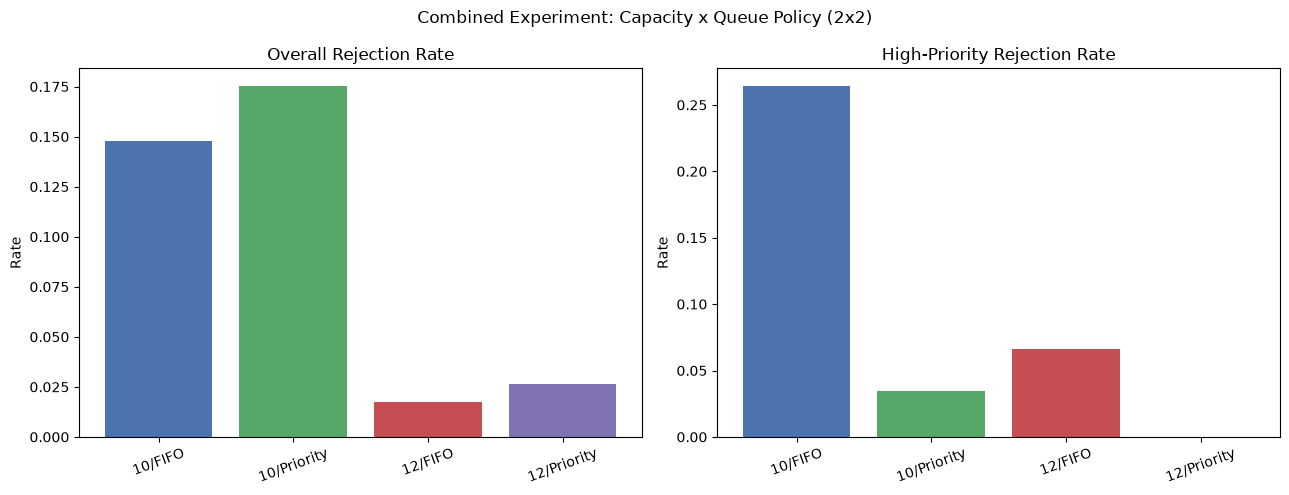

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics_to_plot = ["rejection_rate", "rejection_rate_high"]
titles = ["Overall Rejection Rate", "High-Priority Rejection Rate"]
labels = ["10/FIFO", "10/Priority", f"{chosen_capacity}/FIFO", f"{chosen_capacity}/Priority"]

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    vals = combined_2x2.loc[metric].values
    colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2"]
    ax.bar(labels, vals, color=colors)
    ax.set_ylabel("Rate"); ax.set_title(title)
    ax.tick_params(axis="x", rotation=20)

fig.suptitle("Combined Experiment: Capacity x Queue Policy (2x2)")
fig.tight_layout(); fig.savefig("scenario_comparison_combined.png", dpi=150); plt.show()


In [31]:
combined_new.to_csv("replication_metrics_combined.csv", index=False)
combined_2x2.to_csv("scenario_comparison_combined_2x2.csv")
print("Saved combined experiment results.")


Saved combined experiment results.


### Full Metric Summary (Mean + 95% CI) — Combined Scenario

Same table format as the base case, for the combined (12 beds + priority queue) scenario.

In [32]:
combined_new_summary

,mean,ci_lower,ci_upper,n_replications
metric,,,,
admission_rate,0.973524,0.969605,0.977443,30
rejection_rate,0.026476,0.022557,0.030395,30
avg_waiting_time,1.214860,1.123332,1.306388,30
avg_bed_utilization,0.945546,0.941285,0.949807,30
peak_queue_length,4.566667,4.378467,4.754866,30
pct_time_queue_full,0.002635,0.001494,0.003776,30
pct_time_under_pressure,0.427369,0.399880,0.454859,30
avg_length_of_stay,25.301857,25.130882,25.472831,30
rejection_rate_low,0.060549,0.050291,0.070807,30


## Consolidated Comparison — Base vs. 12 Beds vs. Priority Queue vs. Combined (Uniform Arrivals)

Per Section 5's requirement to include a table comparing scenario confidence intervals: one
row per (metric, scenario) pair, grouped by metric so the four scenarios sit next to each
other for direct comparison, with mean / low CI / high CI as columns.

In [33]:
uniform_scenarios = {
    "base": base_summary,
    "12beds": capacity_summaries[chosen_capacity],
    "priority": queue_policy_summary,
    "combined": combined_new_summary,
}
scenario_order = ["base", "12beds", "priority", "combined"]

all_metrics = ["admission_rate", "rejection_rate", "avg_waiting_time", "avg_bed_utilization",
               "peak_queue_length", "pct_time_queue_full", "pct_time_under_pressure",
               "avg_length_of_stay", "rejection_rate_low", "rejection_rate_medium",
               "rejection_rate_high"]

rows = []
for metric in all_metrics:
    for label in scenario_order:
        r = uniform_scenarios[label].loc[metric]
        rows.append({
            "scenario-metric": f"{metric}__{label}",
            "mean": r["mean"], "low_ci": r["ci_lower"], "high_ci": r["ci_upper"],
            "n_replications": r["n_replications"],
        })

uniform_comparison_table = pd.DataFrame(rows).set_index("scenario-metric")
uniform_comparison_table.to_csv("uniform_arrivals_scenario_ci_comparison.csv")
uniform_comparison_table

,mean,low_ci,high_ci,n_replications
scenario-metric,,,,
admission_rate__base,0.852248,0.846468,0.858028,30.0
admission_rate__12beds,0.982535,0.977682,0.987389,30.0
admission_rate__priority,0.824657,0.817059,0.832256,30.0
admission_rate__combined,0.973524,0.969605,0.977443,30.0
rejection_rate__base,0.147752,0.141972,0.153532,30.0
rejection_rate__12beds,0.017465,0.012611,0.022318,30.0
rejection_rate__priority,0.175343,0.167744,0.182941,30.0
rejection_rate__combined,0.026476,0.022557,0.030395,30.0
avg_waiting_time__base,5.479935,5.386644,5.573227,30.0


**Required visualization:** rejection-rate confidence intervals across all four scenarios
(uniform arrivals).

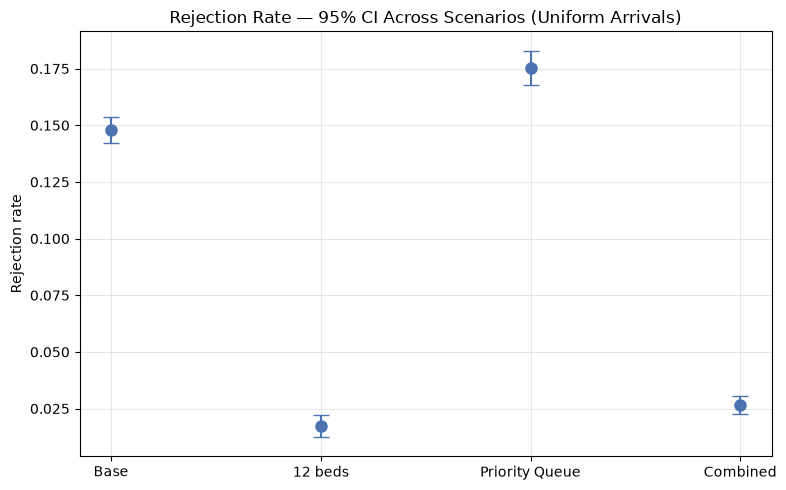

In [34]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [uniform_scenarios[l].loc["rejection_rate", "mean"] for l in scenario_order]
lowers = [uniform_scenarios[l].loc["rejection_rate", "ci_lower"] for l in scenario_order]
uppers = [uniform_scenarios[l].loc["rejection_rate", "ci_upper"] for l in scenario_order]
errors = [[m - l for m, l in zip(means, lowers)], [u - m for u, m in zip(uppers, means)]]

x = np.arange(len(scenario_order))
ax.errorbar(x, means, yerr=errors, fmt="o", capsize=6, color="#4C72B0", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Base", "12 beds", "Priority Queue", "Combined"])
ax.set_ylabel("Rejection rate")
ax.set_title("Rejection Rate — 95% CI Across Scenarios (Uniform Arrivals)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("rejection_rate_ci_uniform_scenarios.png", dpi=150); plt.show()

### Practical Significance — All Metrics (Uniform Arrivals)

Same rule used in Experiment 1's elbow detection (non-overlapping 95% CIs **and** a gap
exceeding the domain threshold: 5 percentage points for rate metrics, 1 hour for time
metrics), now applied to every required metric across the four scenario comparisons.

In [35]:
def compare_scenarios_practical_significance(scenario_summaries, comparisons, metrics):
    """comparisons: list of (comparison_label, label_a, label_b) using keys from
    scenario_summaries. Returns one row per (comparison, metric)."""
    rows = []
    for label, a, b in comparisons:
        for m in metrics:
            row_a = scenario_summaries[a].loc[m]
            row_b = scenario_summaries[b].loc[m]
            is_time = ("waiting" in m) or ("length_of_stay" in m)
            meaningful = is_practically_meaningful(row_a, row_b, is_time_metric=is_time)
            rows.append({
                "comparison": label, "metric": m,
                "scenario_a": a, "scenario_b": b,
                "mean_a": row_a["mean"], "mean_b": row_b["mean"],
                "gap_b_minus_a": row_b["mean"] - row_a["mean"],
                "practically_meaningful": meaningful,
            })
    return pd.DataFrame(rows)

In [36]:
uniform_comparisons = [
    ("Queue Policy vs. Base", "base", "priority"),
    ("Combined vs. Base", "base", "combined"),
    ("Combined vs. Capacity-alone", "12beds", "combined"),
    ("Combined vs. Queue-Policy-alone", "priority", "combined"),
]

uniform_significance = compare_scenarios_practical_significance(
    uniform_scenarios, uniform_comparisons, all_metrics)
uniform_significance.to_csv("practical_significance_uniform.csv", index=False)
uniform_significance

,comparison,metric,scenario_a,scenario_b,mean_a,mean_b,gap_b_minus_a,practically_meaningful
0,Queue Policy vs. Base,admission_rate,base,priority,0.852248,0.824657,-0.027591,False
1,Queue Policy vs. Base,rejection_rate,base,priority,0.147752,0.175343,0.027591,False
2,Queue Policy vs. Base,avg_waiting_time,base,priority,5.479935,2.719277,-2.760659,True
3,Queue Policy vs. Base,avg_bed_utilization,base,priority,0.985534,0.982006,-0.003528,False
4,Queue Policy vs. Base,peak_queue_length,base,priority,5.000000,5.000000,0.000000,False
5,Queue Policy vs. Base,pct_time_queue_full,base,priority,0.097873,0.027231,-0.070643,True
6,Queue Policy vs. Base,pct_time_under_pressure,base,priority,0.927739,0.834813,-0.092926,True
7,Queue Policy vs. Base,avg_length_of_stay,base,priority,29.310972,27.317691,-1.993281,True
8,Queue Policy vs. Base,rejection_rate_low,base,priority,0.100519,0.367232,0.266714,True
9,Queue Policy vs. Base,rejection_rate_medium,base,priority,0.167398,0.088399,-0.078999,True


**Reading the matrix below.** Rows are scenario comparisons, columns are metrics. A cell
shows `-` if the difference is *not* practically meaningful (95% CIs overlap, or the gap is
below the domain threshold). Otherwise it names which scenario is better on that metric and
by how much (percentage points for rate metrics, hours for time metrics, raw count for
`peak_queue_length`). "Better" means higher for `admission_rate`/`avg_bed_utilization` and
lower for every other tracked metric.

In [37]:
RATE_METRICS = {"admission_rate", "rejection_rate", "avg_bed_utilization",
                "pct_time_queue_full", "pct_time_under_pressure",
                "rejection_rate_low", "rejection_rate_medium", "rejection_rate_high"}
TIME_METRICS = {"avg_waiting_time", "avg_length_of_stay"}
COUNT_METRICS = {"peak_queue_length"}
HIGHER_IS_BETTER = {"admission_rate", "avg_bed_utilization"}  # default: lower is better


def format_significance_cell(row):
    if not row["practically_meaningful"]:
        return "-"
    metric = row["metric"]
    a_label, b_label = row["scenario_a"], row["scenario_b"]
    a_val, b_val = row["mean_a"], row["mean_b"]
    higher_is_better = metric in HIGHER_IS_BETTER
    if higher_is_better:
        better_label, better_val, other_val = (
            (a_label, a_val, b_val) if a_val > b_val else (b_label, b_val, a_val))
    else:
        better_label, better_val, other_val = (
            (a_label, a_val, b_val) if a_val < b_val else (b_label, b_val, a_val))
    diff = abs(better_val - other_val)
    if metric in TIME_METRICS:
        return f"{better_label} better by {diff:.2f}h"
    elif metric in COUNT_METRICS:
        return f"{better_label} better by {diff:.2f}"
    else:
        return f"{better_label} better by {diff * 100:.1f}pp"


def build_significance_matrix(significance_df, metrics):
    df = significance_df.copy()
    df["cell"] = df.apply(format_significance_cell, axis=1)
    return df.pivot(index="comparison", columns="metric", values="cell").reindex(columns=metrics)

In [38]:
uniform_significance_matrix = build_significance_matrix(uniform_significance, all_metrics)
uniform_significance_matrix.to_csv("practical_significance_matrix_uniform.csv")
uniform_significance_matrix

metric,admission_rate,rejection_rate,avg_waiting_time,avg_bed_utilization,peak_queue_length,pct_time_queue_full,pct_time_under_pressure,avg_length_of_stay,rejection_rate_low,rejection_rate_medium,rejection_rate_high
comparison,,,,,,,,,,,
Combined vs. Base,combined better by 12.1pp,combined better by 12.1pp,combined better by 4.27h,-,combined better by 0.43,combined better by 9.5pp,combined better by 50.0pp,combined better by 4.01h,-,combined better by 15.7pp,combined better by 26.4pp
Combined vs. Capacity-alone,-,-,combined better by 1.31h,-,combined better by 0.40,-,combined better by 17.4pp,combined better by 1.28h,-,-,combined better by 6.6pp
Combined vs. Queue-Policy-alone,combined better by 14.9pp,combined better by 14.9pp,combined better by 1.50h,-,combined better by 0.43,-,combined better by 40.7pp,combined better by 2.02h,combined better by 30.7pp,combined better by 7.8pp,-
Queue Policy vs. Base,-,-,priority better by 2.76h,-,-,priority better by 7.1pp,priority better by 9.3pp,priority better by 1.99h,base better by 26.7pp,priority better by 7.9pp,priority better by 22.9pp


## 13. Experiment 4 — Demand Stress Test (exponential arrivals)

*Beyond the assignment's required minimum of 3 experiments* — the same 2×2 design from
Experiment 3, repeated under **exponential** interarrival times with the **same mean (2.0h)**
as the base case's uniform(1,3)h distribution.

**Justification:** exponential and uniform distributions with the same mean have very
different variability — exponential has a coefficient of variation of 1, versus roughly 0.33
for uniform(1,3). This isolates the effect of arrival *burstiness* from arrival *volume*,
since the long-run average patient volume is unchanged. This satisfies the assignment's
demand-model experiment category (Section 6: "exponential arrivals... or a time-varying
arrival pattern") and directly tests how robust the capacity/policy conclusions from
Experiment 3 are to more realistic, clustered arrival patterns.

**Expected effect (stated before running):** all four scenarios should perform *worse* than
their uniform-arrival counterparts from Experiment 3, despite an unchanged average arrival
rate, because burstier arrivals create temporary local overload that the system can't always
absorb even when it isn't overloaded on average. We expect the relative ranking between the
four scenarios (which combination is best/worst) to be preserved even as absolute performance
degrades.

In [39]:
stress_configs = {
    "10_fifo":     dict(num_beds=10, queue_discipline="fifo"),
    "10_priority": dict(num_beds=10, queue_discipline="priority"),
    f"{chosen_capacity}_fifo":     dict(num_beds=chosen_capacity, queue_discipline="fifo"),
    f"{chosen_capacity}_priority": dict(num_beds=chosen_capacity, queue_discipline="priority"),
}

stress_replications = {}
stress_summaries = {}
for label, cfg in stress_configs.items():
    key = f"stress_{label}_exp" if "stress_"+label+"_exp" in SEED_OFFSETS else None
    # fall back seed offset if a bed count other than 10/chosen_capacity wasn't pre-registered
    scenario_key = f"stress_{label}_exp"
    if scenario_key not in SEED_OFFSETS:
        SEED_OFFSETS[scenario_key] = 440 + len(SEED_OFFSETS)
    rep_df = run_scenario(scenario_key, num_beds=cfg["num_beds"], queue_capacity=5,
                           queue_discipline=cfg["queue_discipline"],
                           arrival_dist="exponential", arrival_mean=2.0)
    stress_replications[label] = rep_df
    stress_summaries[label] = summarize_with_ci(rep_df)

stress_comparison = pd.DataFrame({label: stress_summaries[label]["mean"] for label in stress_configs}).T
stress_comparison.index.name = "scenario (exponential arrivals)"
stress_comparison[["admission_rate", "rejection_rate", "avg_bed_utilization",
                   "rejection_rate_low", "rejection_rate_high"]]


metric,admission_rate,rejection_rate,avg_bed_utilization,rejection_rate_low,rejection_rate_high
scenario (exponential arrivals),,,,,
10_fifo,0.808959,0.191041,0.950726,0.159016,0.309004
10_priority,0.781831,0.218169,0.939704,0.368006,0.095446
12_fifo,0.923211,0.076789,0.889921,0.061417,0.122914
12_priority,0.900724,0.099276,0.877986,0.169904,0.046894


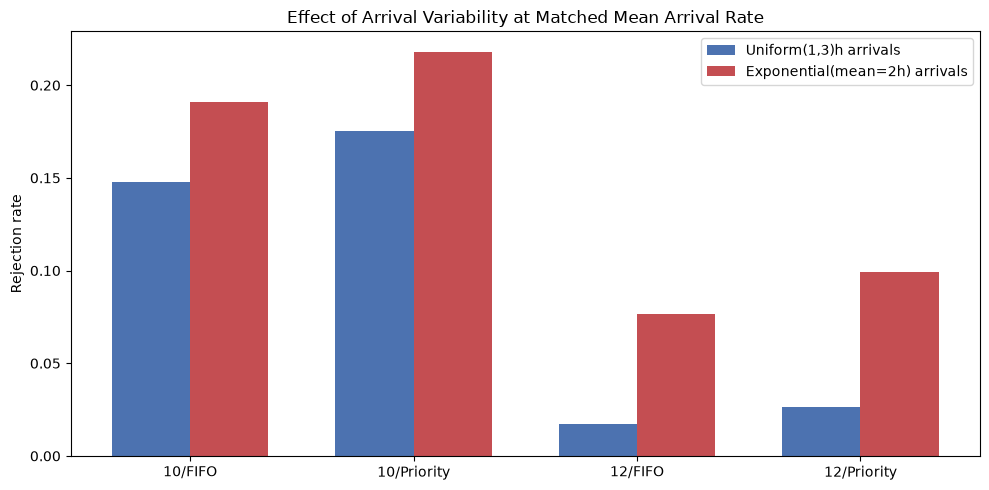

In [40]:
fig, ax = plt.subplots(figsize=(10, 5))
labels = list(stress_configs.keys())
uniform_vals = [combined_2x2.loc["rejection_rate", col] for col in
                ["10 beds / FIFO (base)", "10 beds / Priority",
                 f"{chosen_capacity} beds / FIFO", f"{chosen_capacity} beds / Priority"]]
exp_vals = [stress_summaries[l].loc["rejection_rate", "mean"] for l in labels]

x = np.arange(len(labels)); width = 0.35
ax.bar(x - width/2, uniform_vals, width, label="Uniform(1,3)h arrivals", color="#4C72B0")
ax.bar(x + width/2, exp_vals, width, label="Exponential(mean=2h) arrivals", color="#C44E52")
ax.set_xticks(x); ax.set_xticklabels(["10/FIFO", "10/Priority", f"{chosen_capacity}/FIFO", f"{chosen_capacity}/Priority"])
ax.set_ylabel("Rejection rate")
ax.set_title("Effect of Arrival Variability at Matched Mean Arrival Rate")
ax.legend()
fig.tight_layout(); fig.savefig("scenario_comparison_stress_test.png", dpi=150); plt.show()


In [41]:
for label, rep_df in stress_replications.items():
    rep_df.to_csv(f"replication_metrics_stress_{label}_exp.csv", index=False)
stress_comparison.to_csv("scenario_comparison_stress_test.csv")
print("Saved demand stress-test results.")


Saved demand stress-test results.


## Consolidated Comparison — Base vs. 12 Beds vs. Priority Queue vs. Combined (Exponential Arrivals)

Repeats the consolidated comparison and practical-significance analysis above, but under
**exponential(mean=2h)** arrivals instead of uniform(1,3)h arrivals, reusing the 30-replication
results already computed in the Demand Stress Test experiment. Kept as a fully separate
table/section, not merged with the uniform-arrival results above.

In [42]:
exp_scenarios = {
    "base": stress_summaries["10_fifo"],
    "12beds": stress_summaries[f"{chosen_capacity}_fifo"],
    "priority": stress_summaries["10_priority"],
    "combined": stress_summaries[f"{chosen_capacity}_priority"],
}

rows = []
for metric in all_metrics:
    for label in scenario_order:
        r = exp_scenarios[label].loc[metric]
        rows.append({
            "scenario-metric": f"{metric}__{label}",
            "mean": r["mean"], "low_ci": r["ci_lower"], "high_ci": r["ci_upper"],
            "n_replications": r["n_replications"],
        })

exponential_comparison_table = pd.DataFrame(rows).set_index("scenario-metric")
exponential_comparison_table.to_csv("exponential_arrivals_scenario_ci_comparison.csv")
exponential_comparison_table

,mean,low_ci,high_ci,n_replications
scenario-metric,,,,
admission_rate__base,0.808959,0.795191,0.822726,30.0
admission_rate__12beds,0.923211,0.914592,0.931829,30.0
admission_rate__priority,0.781831,0.768142,0.795520,30.0
admission_rate__combined,0.900724,0.890743,0.910704,30.0
rejection_rate__base,0.191041,0.177274,0.204809,30.0
rejection_rate__12beds,0.076789,0.068171,0.085408,30.0
rejection_rate__priority,0.218169,0.204480,0.231858,30.0
rejection_rate__combined,0.099276,0.089296,0.109257,30.0
avg_waiting_time__base,3.774173,3.586286,3.962061,30.0


**Required visualization:** rejection-rate confidence intervals across all four scenarios
(exponential arrivals).

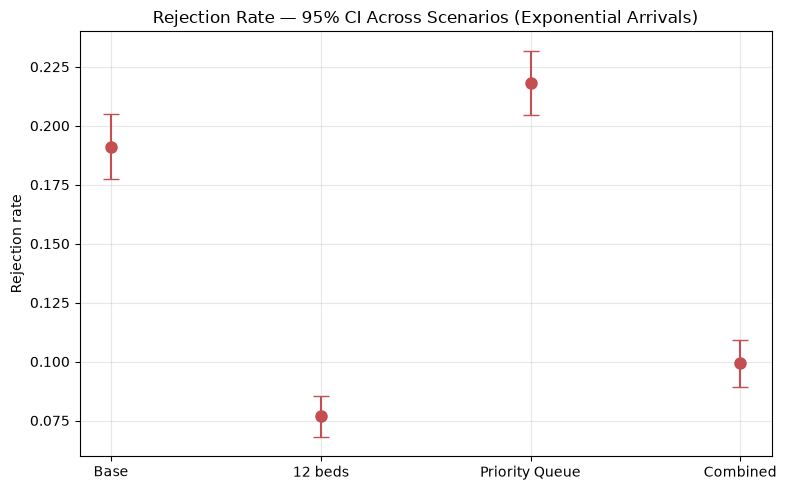

In [43]:
fig, ax = plt.subplots(figsize=(8, 5))
means = [exp_scenarios[l].loc["rejection_rate", "mean"] for l in scenario_order]
lowers = [exp_scenarios[l].loc["rejection_rate", "ci_lower"] for l in scenario_order]
uppers = [exp_scenarios[l].loc["rejection_rate", "ci_upper"] for l in scenario_order]
errors = [[m - l for m, l in zip(means, lowers)], [u - m for u, m in zip(uppers, means)]]

x = np.arange(len(scenario_order))
ax.errorbar(x, means, yerr=errors, fmt="o", capsize=6, color="#C44E52", markersize=8)
ax.set_xticks(x)
ax.set_xticklabels(["Base", "12 beds", "Priority Queue", "Combined"])
ax.set_ylabel("Rejection rate")
ax.set_title("Rejection Rate — 95% CI Across Scenarios (Exponential Arrivals)")
ax.grid(alpha=0.3)
fig.tight_layout(); fig.savefig("rejection_rate_ci_exponential_scenarios.png", dpi=150); plt.show()

### Practical Significance — All Metrics (Exponential Arrivals)

Same rule and comparisons as the uniform-arrival analysis above, computed independently on
the exponential-arrival replications.

In [44]:
exp_comparisons = [
    ("Queue Policy vs. Base", "base", "priority"),
    ("Combined vs. Base", "base", "combined"),
    ("Combined vs. Capacity-alone", "12beds", "combined"),
    ("Combined vs. Queue-Policy-alone", "priority", "combined"),
]

exponential_significance = compare_scenarios_practical_significance(
    exp_scenarios, exp_comparisons, all_metrics)
exponential_significance.to_csv("practical_significance_exponential.csv", index=False)
exponential_significance

,comparison,metric,scenario_a,scenario_b,mean_a,mean_b,gap_b_minus_a,practically_meaningful
0,Queue Policy vs. Base,admission_rate,base,priority,0.808959,0.781831,-0.027128,False
1,Queue Policy vs. Base,rejection_rate,base,priority,0.191041,0.218169,0.027128,False
2,Queue Policy vs. Base,avg_waiting_time,base,priority,3.774173,2.285695,-1.488478,True
3,Queue Policy vs. Base,avg_bed_utilization,base,priority,0.950726,0.939704,-0.011022,False
4,Queue Policy vs. Base,peak_queue_length,base,priority,5.000000,5.000000,0.000000,False
5,Queue Policy vs. Base,pct_time_queue_full,base,priority,0.100324,0.074202,-0.026121,False
6,Queue Policy vs. Base,pct_time_under_pressure,base,priority,0.694868,0.627184,-0.067684,True
7,Queue Policy vs. Base,avg_length_of_stay,base,priority,27.718887,26.750761,-0.968126,False
8,Queue Policy vs. Base,rejection_rate_low,base,priority,0.159016,0.368006,0.208990,True
9,Queue Policy vs. Base,rejection_rate_medium,base,priority,0.202540,0.146937,-0.055603,True


In [45]:
exponential_significance_matrix = build_significance_matrix(exponential_significance, all_metrics)
exponential_significance_matrix.to_csv("practical_significance_matrix_exponential.csv")
exponential_significance_matrix

metric,admission_rate,rejection_rate,avg_waiting_time,avg_bed_utilization,peak_queue_length,pct_time_queue_full,pct_time_under_pressure,avg_length_of_stay,rejection_rate_low,rejection_rate_medium,rejection_rate_high
comparison,,,,,,,,,,,
Combined vs. Base,combined better by 9.2pp,combined better by 9.2pp,combined better by 2.38h,base better by 7.3pp,-,combined better by 6.5pp,combined better by 30.0pp,combined better by 2.20h,-,combined better by 13.6pp,combined better by 26.2pp
Combined vs. Capacity-alone,-,-,-,-,-,-,-,-,12beds better by 10.8pp,-,-
Combined vs. Queue-Policy-alone,combined better by 11.9pp,combined better by 11.9pp,-,priority better by 6.2pp,-,-,combined better by 23.2pp,combined better by 1.23h,combined better by 19.8pp,combined better by 8.1pp,-
Queue Policy vs. Base,-,-,priority better by 1.49h,-,-,-,priority better by 6.8pp,-,base better by 20.9pp,priority better by 5.6pp,priority better by 21.4pp


## 14. Master Scenario Comparison Table

In [46]:
all_scenarios = {
    "Base (10/FIFO/Uniform)": base_summary["mean"],
    "Queue Policy (10/Priority/Uniform)": queue_policy_summary["mean"],
}
for beds in capacity_bed_counts:
    all_scenarios[f"Capacity ({beds} beds/FIFO/Uniform)"] = capacity_summaries[beds]["mean"]
all_scenarios[f"Combined ({chosen_capacity}/Priority/Uniform)"] = combined_new_summary["mean"]
for label in stress_configs:
    all_scenarios[f"Stress ({label}/Exponential)"] = stress_summaries[label]["mean"]

master_comparison = pd.DataFrame(all_scenarios).T
master_comparison.to_csv("scenario_summary_all.csv")
master_comparison[["admission_rate", "rejection_rate", "avg_bed_utilization", "avg_waiting_time"]]


metric,admission_rate,rejection_rate,avg_bed_utilization,avg_waiting_time
Base (10/FIFO/Uniform),0.852248,0.147752,0.985534,5.479935
Queue Policy (10/Priority/Uniform),0.824657,0.175343,0.982006,2.719277
Capacity (10 beds/FIFO/Uniform),0.856525,0.143475,0.985409,5.419010
Capacity (11 beds/FIFO/Uniform),0.930900,0.069100,0.981062,4.466248
Capacity (12 beds/FIFO/Uniform),0.982535,0.017465,0.959235,2.525838
Capacity (14 beds/FIFO/Uniform),1.000000,0.000000,0.833485,0.128935
Capacity (16 beds/FIFO/Uniform),1.000000,0.000000,0.726916,0.005101
Capacity (18 beds/FIFO/Uniform),1.000000,0.000000,0.647940,0.000105
Capacity (20 beds/FIFO/Uniform),1.000000,0.000000,0.582767,0.000000
Capacity (24 beds/FIFO/Uniform),1.000000,0.000000,0.487099,0.000000


**Note:** "Base (10/FIFO/Uniform)" and "Capacity (10 beds/FIFO/Uniform)" are the identical
configuration, run with two different independent seed sets. They land close together
(admission rate within ~1 percentage point), which is a useful internal consistency check —
confirming the results are driven by the scenario parameters, not by which particular seeds
were drawn.